
### Tasks

**Remember this is a real research example, not an exam! You're welcome (and encouraged actually!) to use all the tutorials/answers/hack you find online!**


1) Read in `solutions/transient.npy`. This is a (100 x 3) numpy array, containing some time-series measurements from a transient phenomenon. The first column is time (arbitrary units), the second column is the flux (arbitrary units), and the third column are homoescedastic measurement uncertainties on the flux. Plot this data with the uncertainties.

2) One possible model for this data is a sharp burst with an exponential tail rising above a nominal background level. This model can be described as:

$y = b$, for $t<t_0$

$y = b + A\exp[-\alpha(t-t_0)]$, for $t\geq t_0$

where $b$ is the background amplitude, $A$ is the burst amplitude, $t_0$ is the burst epoch, and $\alpha$ encodes how rapidly the burst dies off.

Code this burst model, and code a likelihood function for this data with the burst model. *Hint: This is similar in spirit to the likelihood when fitting polynomials to data, except now $x$ is time, and the polynomial model is now the burst model.* 

3) Using one of the MCMC sampler that we looked at in class (`emcee`, `pymc`), perform a Bayesian analysis that recovers an MCMC chain of posterior probability samples for the joint parameter space of $\{b,A,t_0,\alpha\}$. You must decide on how man
y samples are appropriate for running your MCMC. For your priors, make them $b\in \mathrm{Uniform}[0,50]$, $A\in \mathrm{Uniform}[0,50]$, $t_0\in \mathrm{Uniform}[0,100]$, and $\ln\alpha\in \mathrm{Uniform}[-5,5]$ (careful: uniform in $\ln\alpha$, not $\alpha$).

4) Perform an appropriate check to burn-in your chain, and thin the chain by selecting only points every auto-correlation length. If you are left with a small number of samples after thinning then you may need to run your MCMC for longer in (3).

5) Make a corner plot of the $4$-D parameter space, with labels, $[68,95]\%$ credible levels and quantiles, and titles.

6) Now choose $100$ samples randomly from your burned, thinned chain and plot the $100$ corresponding burst time-series on a figure along with the original data. You may want to choose a transparency for these $100$ burst curves that allows you to see everything nicely. These are showing the posterior spread of model solutions that are consistent with the data.

7) For each parameter, find the median and 90% credible region of the marginalized distribution and quote results as, for instance, $t_0=X^{+Y}_{-Z}$ 



In [352]:
import numpy as np
from scipy import stats
from scipy import optimize
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

import emcee

In [353]:
#reading data
data = np.load("/Users/albertodufour/code/astrostatistics_bicocca_2025/solutions/transient.npy")

time ,flux, err = data.T

Text(0, 0.5, 'flux')

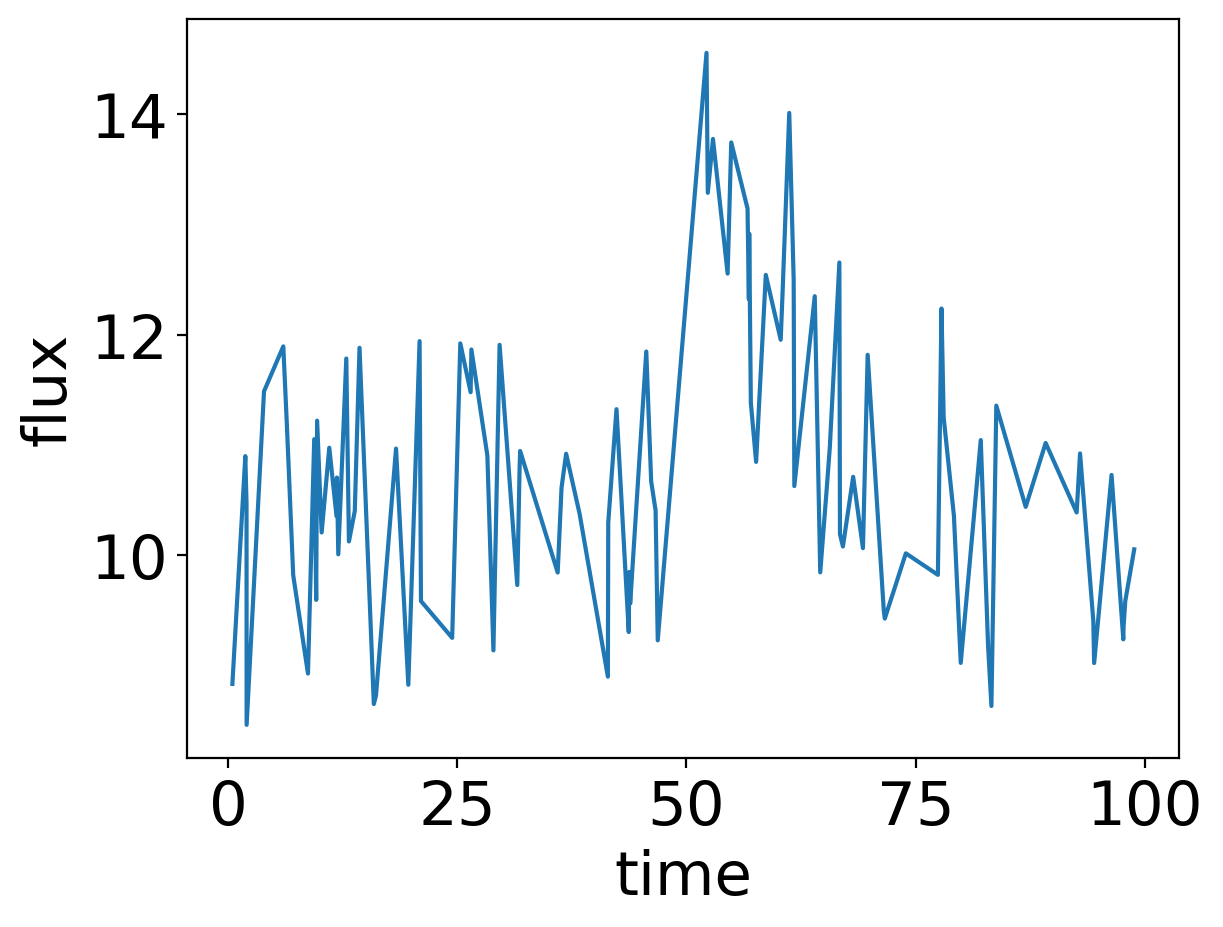

In [354]:
plt.plot(time, flux)
plt.xlabel("time")
plt.ylabel("flux")

pars: [49.90476567  0.11890266  4.98490334 10.28787283]
stds: [2.64444813e+07 2.84576880e-02 1.56741280e+07 1.25368750e-01]
[[ 6.99310590e+14 -2.87868021e+04 -4.14494183e+14 -2.73383248e+05]
 [-2.87868021e+04  8.09840007e-04  1.70624842e+04  1.49876963e-03]
 [-4.14494183e+14  1.70624842e+04  2.45678287e+14  1.62039260e+05]
 [-2.73383248e+05  1.49876963e-03  1.62039260e+05  1.57173235e-02]]


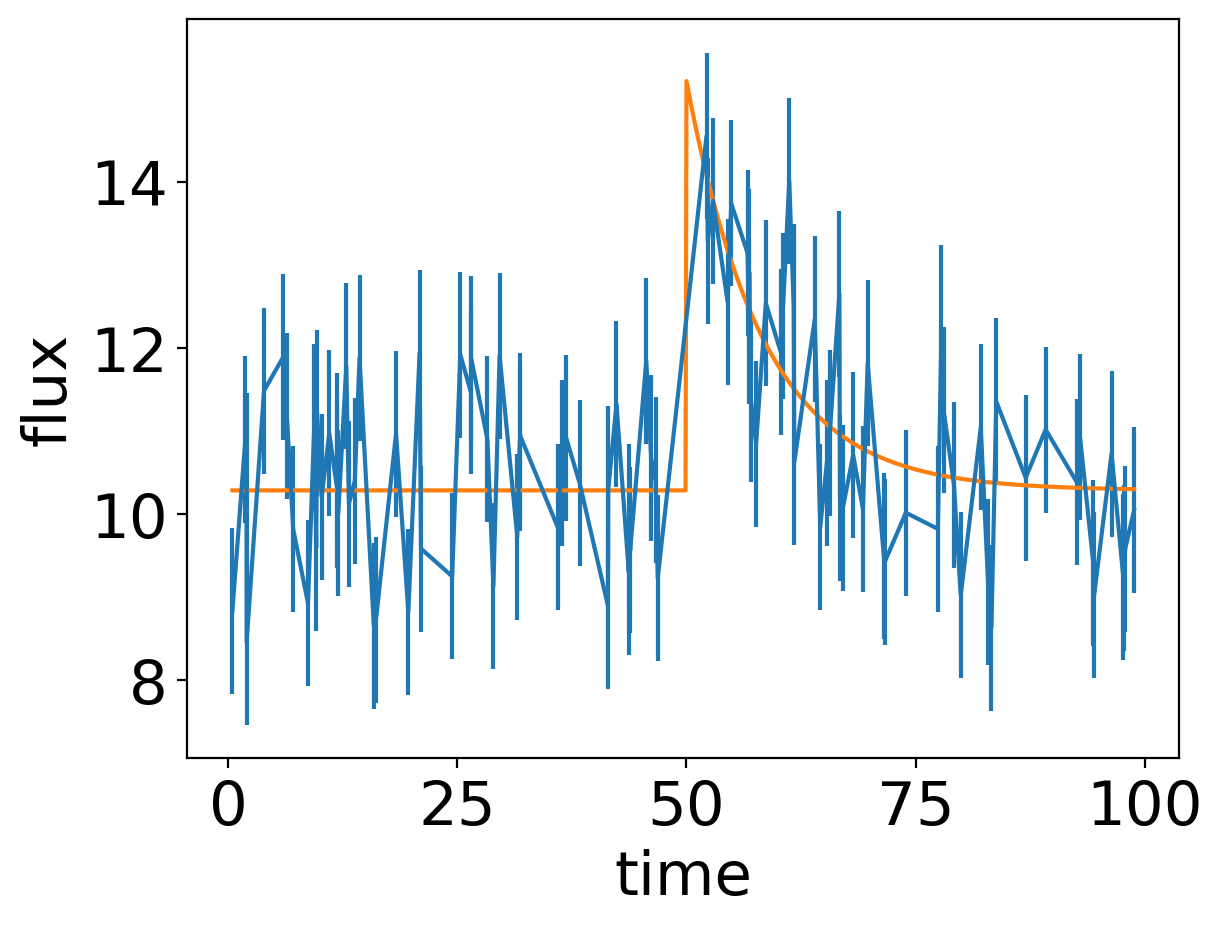

In [ ]:
# fitting
def model(t, par):
    t0, alpha, A, b = par
    return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))

initial_guess = [50, 1/10, 5, 10]
bounds = ([20, 0, 0, 5], [80, 1, 10, 20])
par_fit, cov_fit = optimize.curve_fit(lambda t, *par: model(t, par), time, flux, p0=initial_guess, bounds=bounds)
par_fit, cov_fit = optimize.curve_fit(lambda t, *par: model(t, par), time, flux, p0=par_fit)


plt.errorbar(time, flux, yerr=err)

xgrid = np.linspace(np.min(time), np.max(time), 1000)
plt.plot(xgrid, model(xgrid, par_fit))



plt.xlabel("time")
plt.ylabel("flux")

print(f"pars: {par_fit}\nstds: {np.sqrt(np.diag(cov_fit))}")

#EMCEE

In [376]:
#----------------------- Likelihood and Priors --------------
#! crucial: must use all info available (x,y, err)
def logLikelihood(par, data):
    t, y, sigma_y = data
    y_fit = model(t, par)
    return -0.5 * np.sum((y-y_fit)**2/sigma_y**2)

def logPrior(par):
    t0, alpha, A, b = par
    if (20 < t0 < 100) and (0 < alpha < 1) and (0 < A < 10) and (0 < b < 20):
        return 1.0  # Flat prior within bounds
    return -np.inf  # Outside the bounds

def logPosterior(par, data):
    return logLikelihood(par,data) + logPrior(par)


In [382]:
#--------------- MCMC -----------------
ndim = 4 
nwalkers = 20 
nsteps = int(1e5)  # number of MCMC steps to take **for each walker**

# Configure the bounds based on your prior
t0_bounds = (20, 100)
alpha_bounds = (0, 1)
A_bounds = (0, 10)
b_bounds = (0, 20)

# Function to generate initial walkers within bounds
def generate_initial_walkers(nwalkers):
    walkers = []
    for _ in range(nwalkers):
        t0 = np.random.uniform(*t0_bounds)
        alpha = np.random.uniform(*alpha_bounds)
        A = np.random.uniform(*A_bounds)
        b = np.random.uniform(*b_bounds)
        walkers.append([t0, alpha, A, b])
    return np.array(walkers)

# Initialize walkers
starting_guesses = generate_initial_walkers(nwalkers)
# starting_guesses = par_fit + 1e-1* np.random.randn(nwalkers, ndim)
print("Initial Walker Positions:")
print(starting_guesses)

# emcee
sampler = emcee.EnsembleSampler(nwalkers, ndim, logPosterior, args=[data.T])
sampler.run_mcmc(starting_guesses, nsteps, progress=True)
print("done")

Initial Walker Positions:
[[5.25017998e+01 9.63093890e-01 2.83513782e+00 5.26157561e+00]
 [4.66805917e+01 5.72317016e-01 8.94869740e+00 3.52563280e+00]
 [4.23743038e+01 5.81679843e-01 4.54334242e+00 8.94645775e+00]
 [8.56587410e+01 9.23878303e-01 4.81306966e+00 1.37470359e+01]
 [8.40846969e+01 5.18366410e-01 2.94316409e+00 1.27616920e+01]
 [6.68087280e+01 9.01562820e-01 5.24070368e-01 1.82026277e+01]
 [6.27545623e+01 1.56761160e-02 3.44702179e+00 1.44866713e+01]
 [5.90746470e+01 9.80159037e-01 4.22610074e+00 6.53270459e+00]
 [8.57337548e+01 5.47906699e-01 6.82326579e+00 1.61140468e+01]
 [7.37142037e+01 4.22407495e-01 1.24796448e+00 1.16049633e+01]
 [9.17946661e+01 4.18892427e-01 9.10725235e+00 1.00705564e+01]
 [6.96673250e+01 8.32988476e-01 5.64597110e+00 1.81938679e+00]
 [9.84783521e+01 2.45849302e-01 7.10505329e+00 1.01022688e+01]
 [5.83018109e+01 2.43940819e-01 7.22150766e+00 2.25576530e+00]
 [9.92362647e+01 8.45373537e-01 5.34508940e+00 8.49105912e+00]
 [4.29171706e+01 5.01591471e-

100%|██████████| 100000/100000 [00:36<00:00, 2747.28it/s]

done


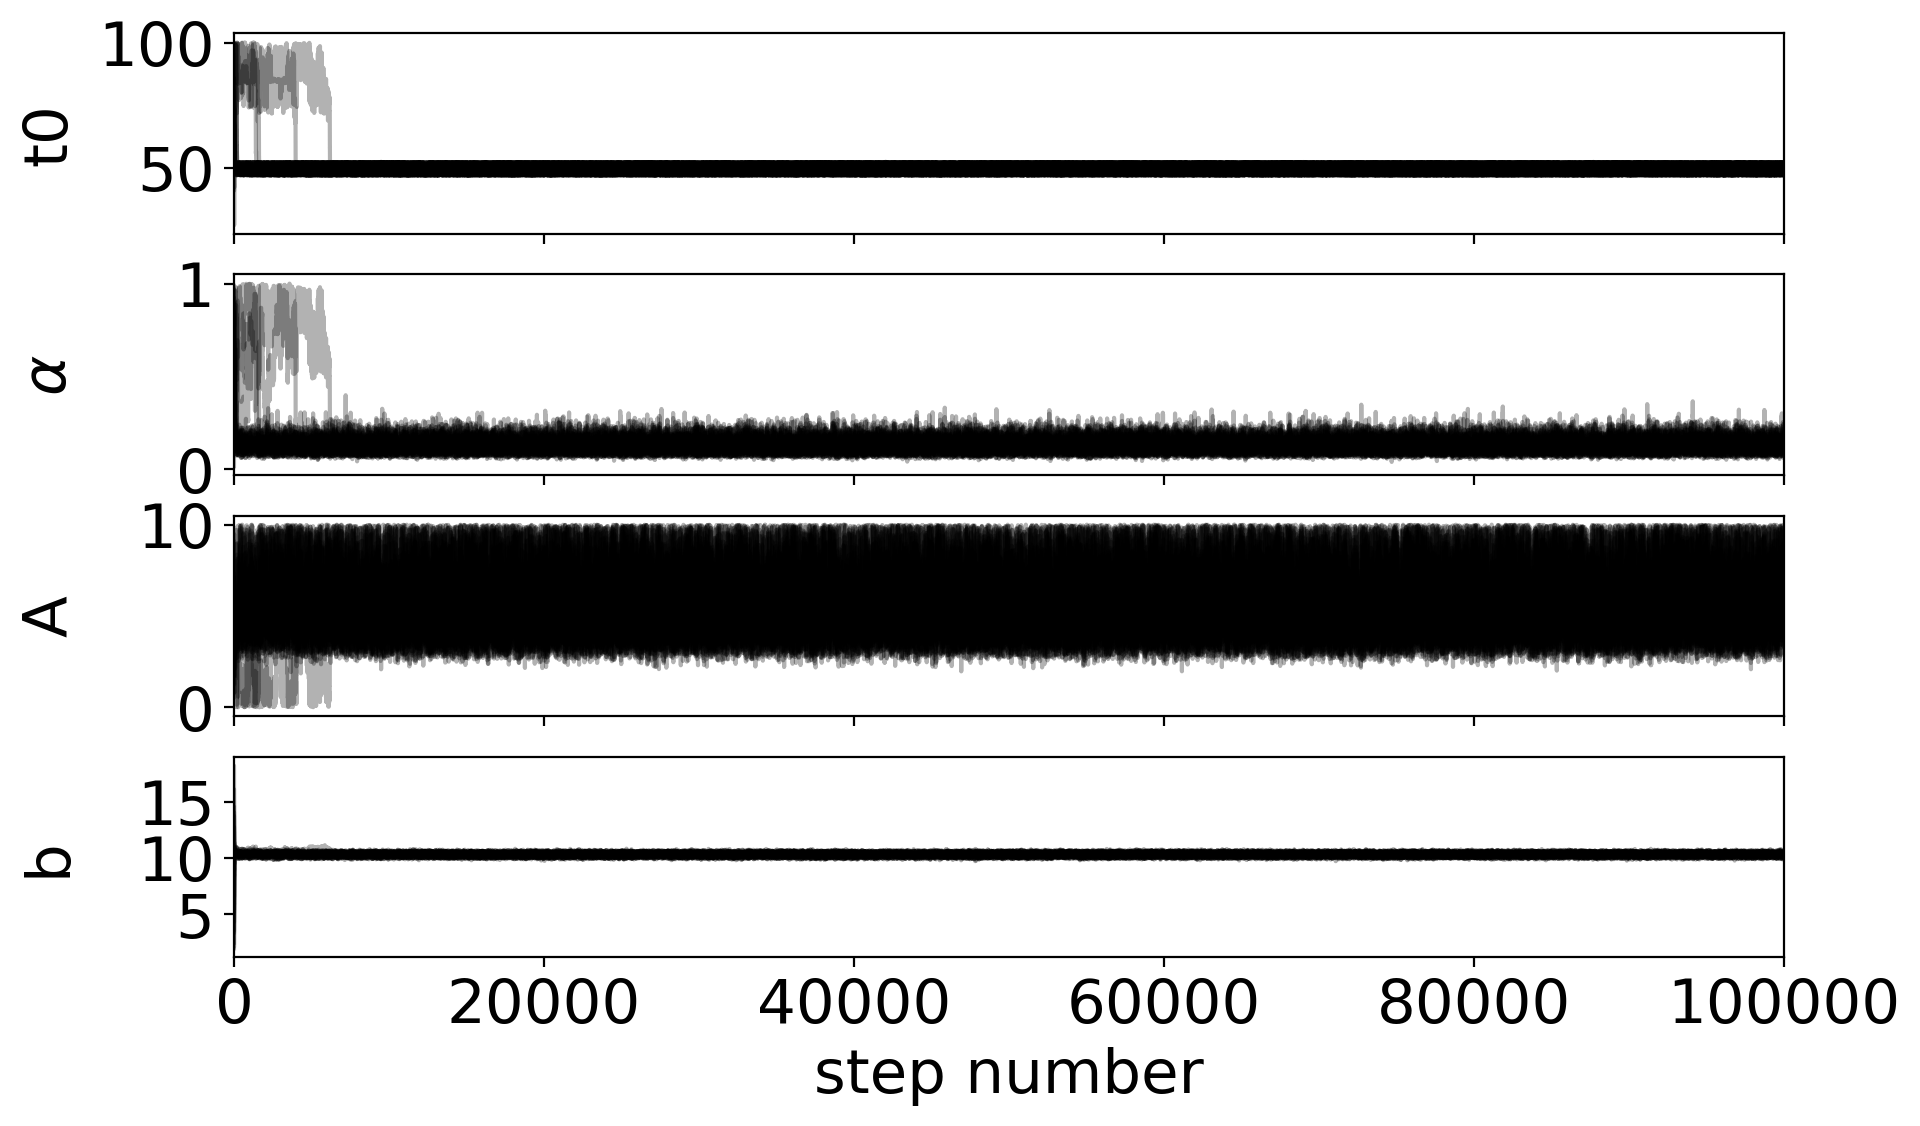

In [383]:
#----------- PRELIMINARY PLOTTING---------------
fig, axes = plt.subplots(4, figsize=(10, 6), sharex=True)
#getting the whole chain
samples = sampler.get_chain()
labels = ["t0",r"$\alpha$","A","b"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");


In [387]:
#------------ ANALYSING RESULTS ----------------
burn = int(nsteps*nwalkers/500) # "burn-in" period to let chains stabilize
print(f"burn: {burn}")

# Get the autocorrelation times
autocorr = sampler.get_autocorr_time()
print("Autocorrelation times:", autocorr)

# Calculate a single thinning value as the maximum autocorrelation time
thin = int(np.ceil(np.max(autocorr))) + 1  # Use the maximum autocorr rounded up

# Get the trace after discarding the burn-in and applying thinning
emcee_trace = sampler.get_chain(discard=burn, thin=thin, flat=True)
flat_trace = emcee_trace.flatten()

burn: 4000
Autocorrelation times: [585.73073996 531.28160053  99.87326915  93.97655756]


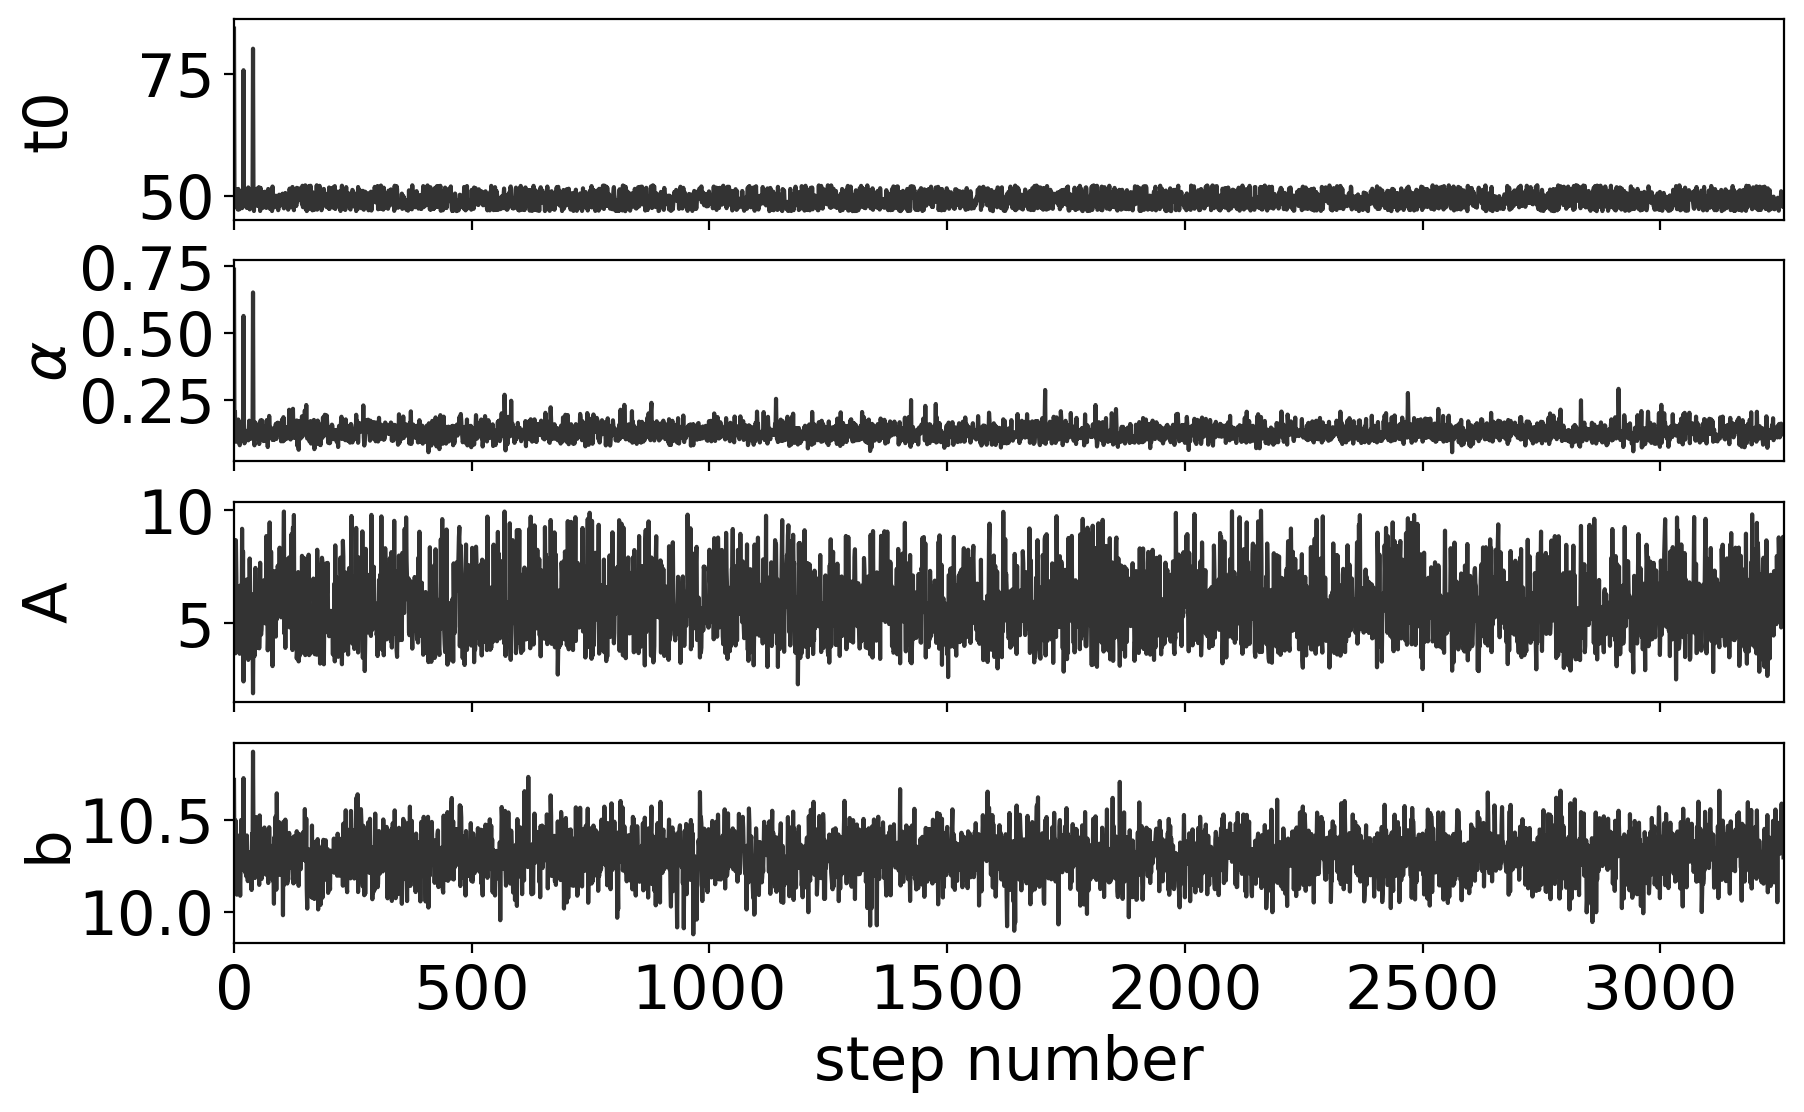

In [389]:
fig, axes = plt.subplots(4, figsize=(10, 6), sharex=True)
labels = ["t0",r"$\alpha$","A","b"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(emcee_trace[:, i], "k", alpha=0.8)
    ax.set_xlim(0, len(emcee_trace))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");


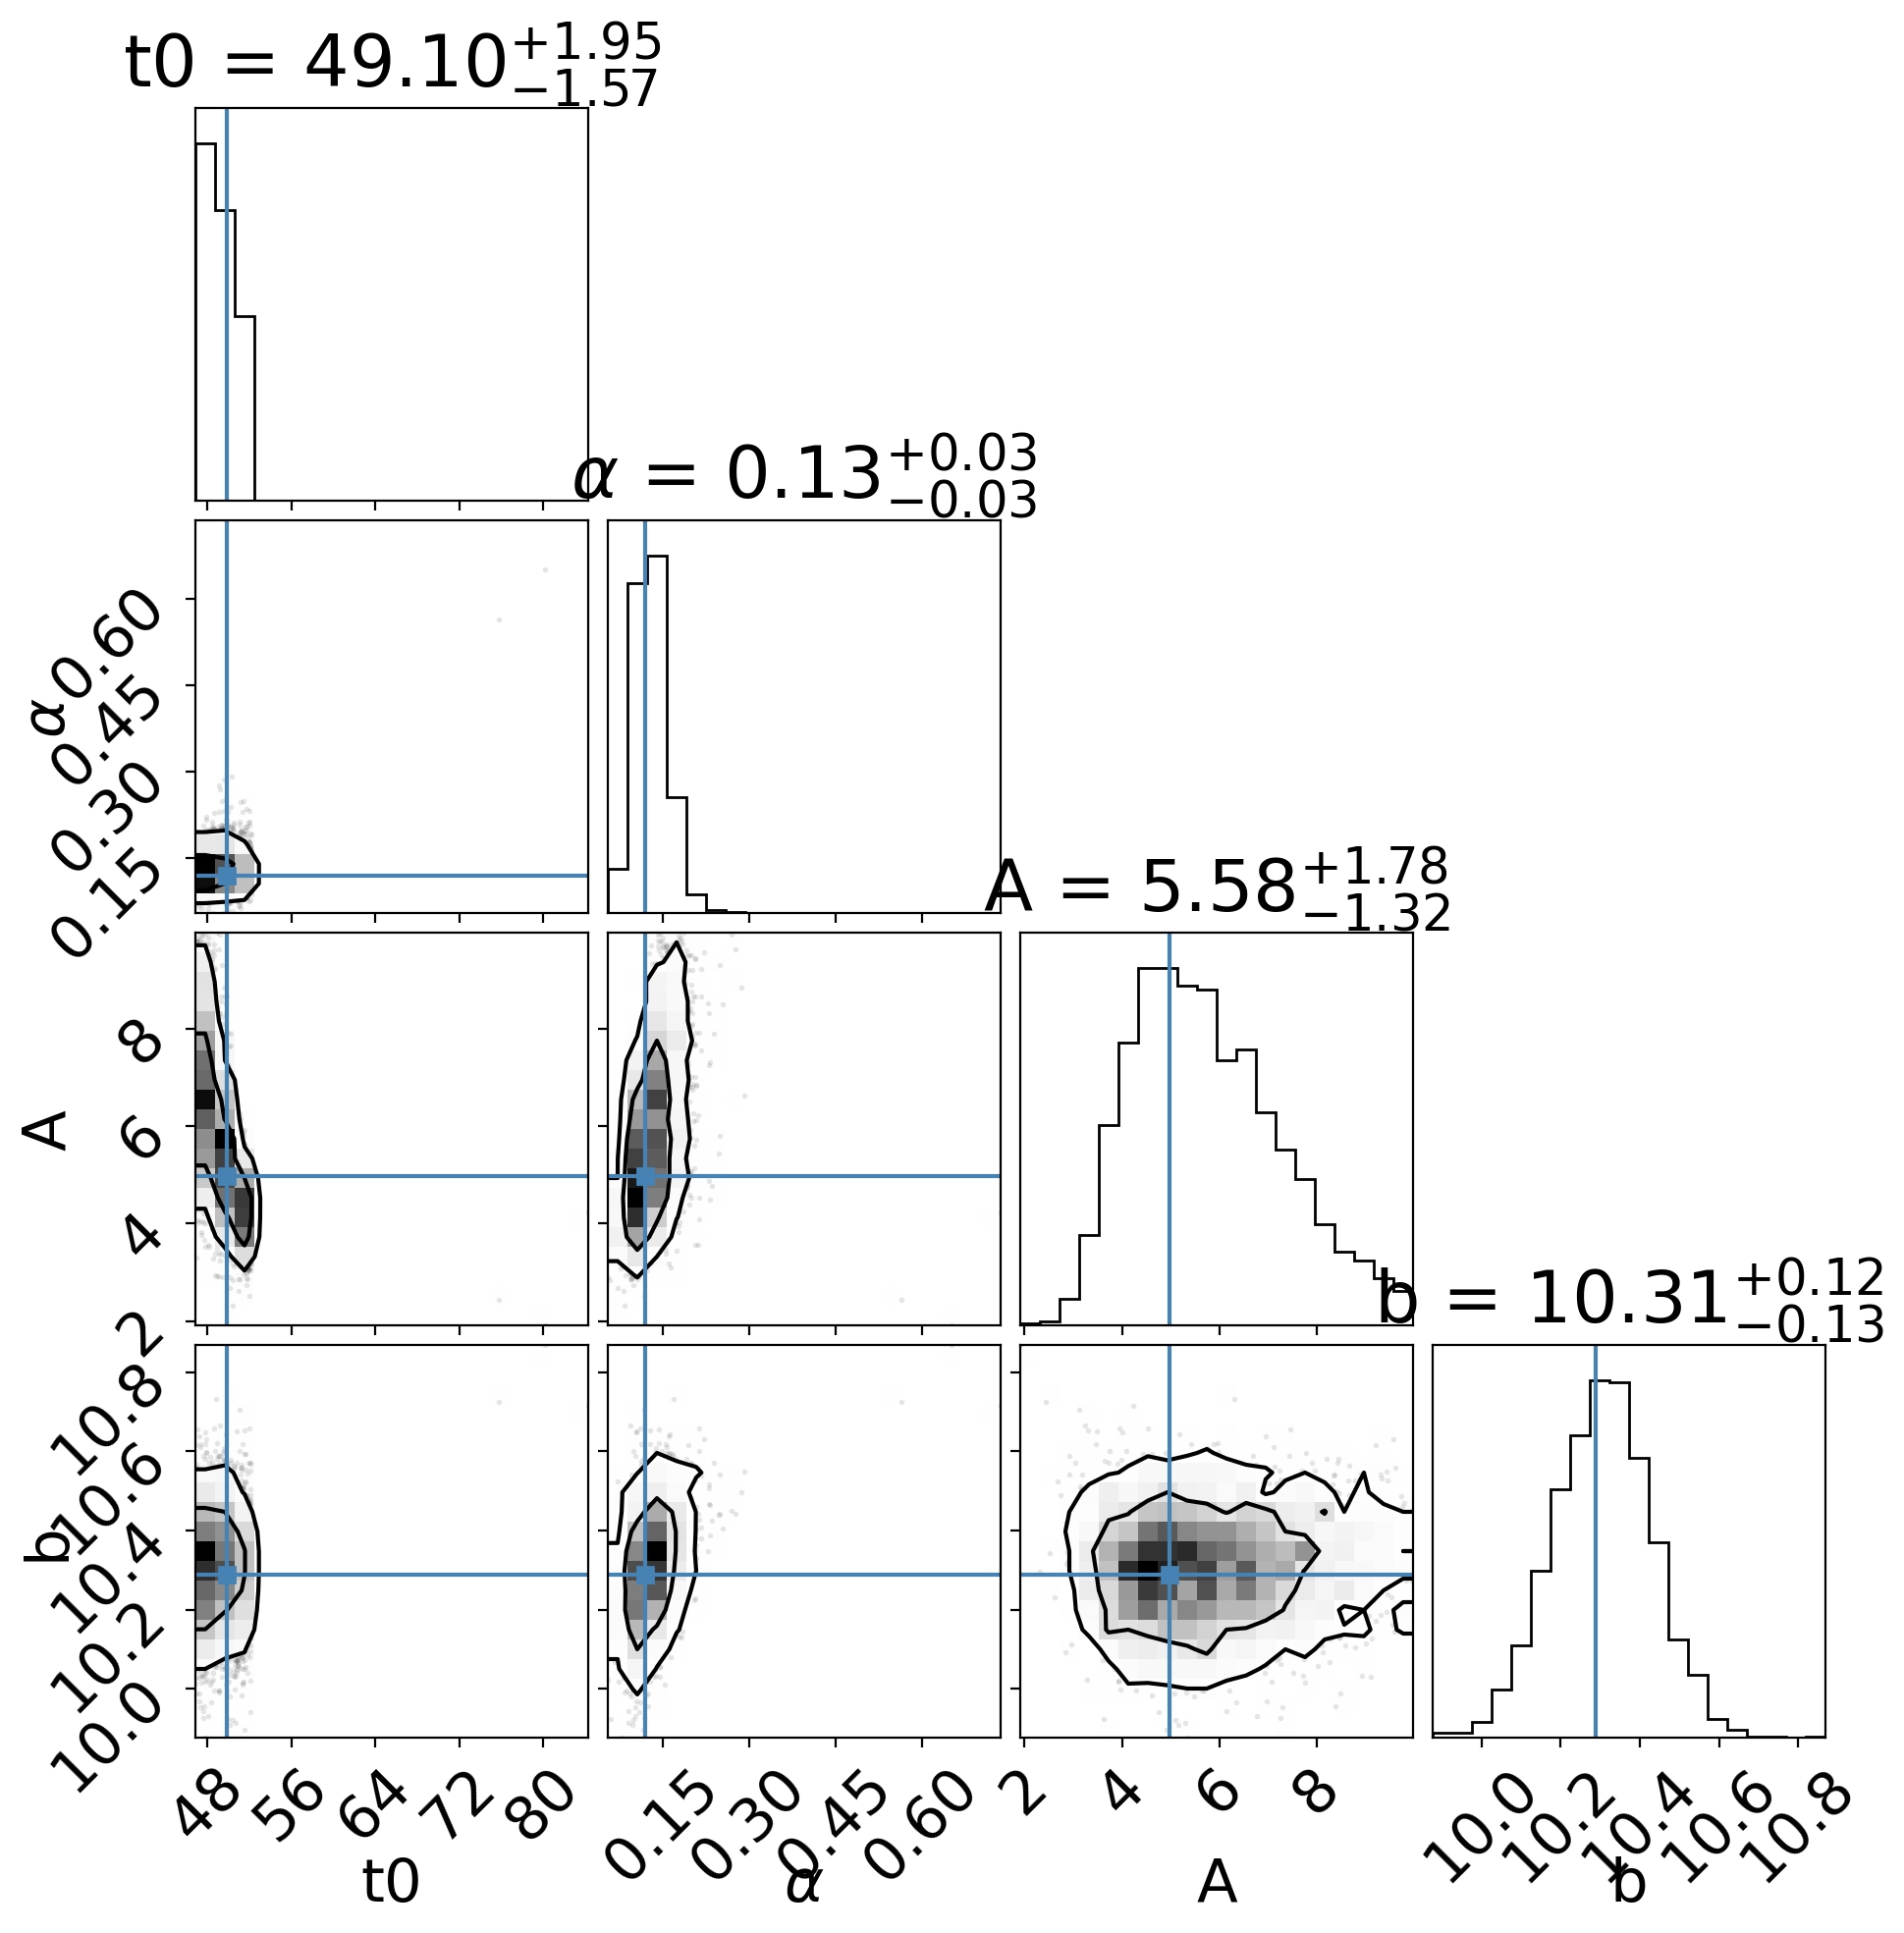

In [392]:
#-------------- CORNER PLOT --------------
from corner import corner
corner(emcee_trace, labels=labels,levels=[0.68,0.95], show_titles=True, truths=par_fit)
plt.show()